In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    mean_squared_error, 
    root_mean_squared_error,
    mean_absolute_error, 
    r2_score
)
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')
!pip install xgboost
from xgboost import XGBClassifier
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)




[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


1. Adding The Fun stuff
- Above is where we added all the code that import model learning and graph developing. In here we installed XG Boost model 

2. Creating a New Dataset
- In this area of coding we took are dataset and inserted two rounds to create a average score for a new dataset we also would clean it up through removing variables such as "total_score" , "avg_round_score" and we created the variable "made_cut".


In [80]:
df = pd.read_csv('C:\\Users\\sawye\\Downloads\\DataScience(1)\\masters_avg_dataset_cleaned.csv')
df.head()

,player_name,sg_putt,sg_arg,sg_app,sg_ott,sg_t2g,distance,accuracy,gir,prox_fw,avg_round_score,made_cut
0,"McIlroy, Rory",0.5215,-0.2595,2.844,1.0255,3.6100,317.25,0.607145,0.694445,32.00745,-3.0,1
1,"Rose, Justin",3.6760,0.8315,0.871,-0.2465,1.4560,291.40,0.750000,0.666670,46.55155,-4.0,1
2,"Reed, Patrick",-0.2550,1.7165,0.420,0.7500,2.8865,296.70,0.892855,0.666665,43.46480,-1.5,1
3,"Scheffler, Scottie",0.9720,1.5205,0.928,0.2110,2.6600,303.30,0.714290,0.638890,36.37200,-2.5,1
4,"Im, Sungjae",2.0335,0.5790,-0.105,0.1240,0.5980,300.30,0.714285,0.666670,33.06530,-1.5,1


In [81]:
def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)


def clean_data(df: pd.DataFrame) -> pd.DataFrame:
   
    df = df.copy()

    
    if "avg_round_score" in df.columns:
        df = df.drop(columns=["avg_round_score"])
        print("Removed: avg_round_score")

  
    if "made_cut" not in df.columns:
        print("'made_cut' not found → creating it...")

        if "position" in df.columns:
            df["position"] = df["position"].astype(str)
            df["position"] = df["position"].str.replace("T", "", regex=False)
            df["position"] = df["position"].replace(
                ["CUT", "WD", "DQ", "MDF"], np.nan
            )
            df["position"] = pd.to_numeric(df["position"], errors="coerce")
            df["made_cut"] = df["position"].notna().astype(int)

        elif "total_score" in df.columns:
            cutoff = df["total_score"].nsmallest(50).max()
            df["made_cut"] = (df["total_score"] <= cutoff).astype(int)

        else:
            raise ValueError("Cannot create 'made_cut' (no position or total_score).")

    return df


def main():
    df = load_data(r"C:\\Users\\sawye\\Downloads\\DataScience(1)\\masters_avg_dataset_cleaned.csv")

    df = clean_data(df)

    print("\nFINAL COLUMNS:")
    print(df.columns.tolist())

    print("\nSAMPLE DATA:")
    print(df.head())


if __name__ == "__main__":
    main()

Removed: avg_round_score

FINAL COLUMNS:
['player_name', 'sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'distance', 'accuracy', 'gir', 'prox_fw', 'made_cut']

SAMPLE DATA:
          player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g  distance  \
0       McIlroy, Rory   0.5215 -0.2595   2.844  1.0255  3.6100    317.25   
1        Rose, Justin   3.6760  0.8315   0.871 -0.2465  1.4560    291.40   
2       Reed, Patrick  -0.2550  1.7165   0.420  0.7500  2.8865    296.70   
3  Scheffler, Scottie   0.9720  1.5205   0.928  0.2110  2.6600    303.30   
4         Im, Sungjae   2.0335  0.5790  -0.105  0.1240  0.5980    300.30   

   accuracy       gir   prox_fw  made_cut  
0  0.607145  0.694445  32.00745         1  
1  0.750000  0.666670  46.55155         1  
2  0.892855  0.666665  43.46480         1  
3  0.714290  0.638890  36.37200         1  
4  0.714285  0.666670  33.06530         1  


3. Basic Model
- The model is a linear regression model that incorporates the new dataset created that will predict the probability of the players making the cut. 

- The beginning of the section of code is the data checking if avg_round was removed and if made_cut was added to the dataset before runing the model.

- sg_putt, sg_arg, sg_app, sg_ott, sg_t2g, distance, accuracy, gir, prox_fw are all the variables included with made_cut that was used in the training of the model. These variables repersent golf_statistics that are crucial to a players game.

- Standard scaler is used in the function because as a linear regression model we want the model taking in every variable the same.

- The results of the model is it prints the minimum stat profile a player can have to make the cut.


In [82]:
def load_data(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)


def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "avg_round_score" in df.columns:
        df = df.drop(columns=["avg_round_score"])

    if "made_cut" not in df.columns:
        raise ValueError("Dataset must contain made_cut column.")

    df["made_cut"] = df["made_cut"].astype(int)

    return df


def prepare_features(df: pd.DataFrame):
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "distance",
        "accuracy",
        "gir",
        "prox_fw"
    ]

    X = df[features].copy()
    y = df["made_cut"]

    X = X.fillna(X.mean())

    return X, y


def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    return model, scaler, X_test, y_test, y_pred


def evaluate_model(y_test, y_pred):
    print("LOGISTIC REGRESSION RESULTS")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))


def find_minimum_profile(df: pd.DataFrame) -> pd.Series:
    made_cut_df = df[df["made_cut"] == 1]

    profile_features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "distance",
        "accuracy",
        "gir",
        "prox_fw"
    ]

    minimum_profile = made_cut_df[profile_features].quantile(0.25)

    print("\nMINIMUM PROFILE TO MAKE THE CUT")
    print(minimum_profile)

    return minimum_profile


def print_players_meeting_profile(df: pd.DataFrame, minimum_profile: pd.Series):
    players = df.copy()

    for feature in minimum_profile.index:
        players = players[players[feature] >= minimum_profile[feature]]

    print("\nPLAYERS WHO MEET OR BEAT THE MINIMUM PROFILE")

    if "player_name" in players.columns:
        print(players[["player_name"] + minimum_profile.index.tolist()])
    else:
        print(players[minimum_profile.index.tolist()])


def main():
    df = load_data(r"C:\\Users\\sawye\\Downloads\\DataScience(1)\\masters_avg_dataset_cleaned.csv")

    df = prepare_data(df)

    X, y = prepare_features(df)

    model, scaler, X_test, y_test, y_pred = train_model(X, y)

    evaluate_model(y_test, y_pred)

    minimum_profile = find_minimum_profile(df)

    print_players_meeting_profile(df, minimum_profile)


if __name__ == "__main__":
    main()

LOGISTIC REGRESSION RESULTS
Accuracy: 0.8947368421052632

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83         7
           1       0.86      1.00      0.92        12

    accuracy                           0.89        19
   macro avg       0.93      0.86      0.88        19
weighted avg       0.91      0.89      0.89        19


Confusion Matrix:
[[ 5  2]
 [ 0 12]]

MINIMUM PROFILE TO MAKE THE CUT
sg_putt      -0.252875
sg_arg       -0.327750
sg_app       -0.196750
sg_ott       -0.242250
sg_t2g       -0.370000
distance    294.187500
accuracy      0.687502
gir           0.611110
prox_fw      33.101413
Name: 0.25, dtype: float64

PLAYERS WHO MEET OR BEAT THE MINIMUM PROFILE
           player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g  distance  \
3   Scheffler, Scottie   0.9720  1.5205  0.9280  0.2110  2.6600    303.30   
5   DeChambeau, Bryson   1.7180  1.8530  0.3295  0.7315  2.9135    307.45   
24      Be

4. Printing linear model results
- This code uses a logistic regression model to estimate which Masters golfers have at least a 70% chance of making the cut based on performance statistics.

- Before training the model, the feature data is scaled using StandardScaler. Scaling is important for logistic regression because the model works better when all variables are on a similar scale. After scaling, the logistic regression model is trained using the full dataset.

- The line of code below is repeated 3 times to print all the golfers who are over that 70% chance threshold that the model us deeming the cut line.

- Overall, this code helps identify golfers who are most likely to make the cut based on their performance metrics.

In [83]:
df = pd.read_csv(r"C:\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv")

features = [
    "sg_putt", "sg_arg", "sg_app", "sg_ott",
    "sg_t2g", "gir", "prox_fw", "accuracy", "distance"
]

X = df[features].copy()
y = df["made_cut"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

prob = model.predict_proba(X_scaled)[:, 1]

results = X.copy()
results["prob_make_cut"] = prob
results["player_name"] = df["player_name"]

cut_players = results[results["prob_make_cut"] >= 0.7]

print(f"\nPlayers with >=70% chance: {len(cut_players)}")

print("\n--- SAFE PLAYERS ---\n")
print(
    cut_players[["player_name", "prob_make_cut"]]
    .sort_values(by="prob_make_cut", ascending=False)
    .to_string(index=False)
)

print("\n--- AVERAGE STATS OF SAFE PLAYERS ---\n")
print(
    cut_players.drop(columns=["player_name", "prob_make_cut"]).mean()
)


Players with >=70% chance: 50

--- SAFE PLAYERS ---

       player_name  prob_make_cut
      Rose, Justin       0.997121
DeChambeau, Bryson       0.995823
    Conners, Corey       0.993482
   Hatton, Tyrrell       0.990802
      Lowry, Shane       0.989227
     McIlroy, Rory       0.988765
Scheffler, Scottie       0.987886
     McCarty, Matt       0.985544
        Day, Jason       0.981929
     Reed, Patrick       0.981211
  Morikawa, Collin       0.979133
 Matsuyama, Hideki       0.968795
  Hojgaard, Rasmus       0.967789
  Fleetwood, Tommy       0.967305
     Aberg, Ludvig       0.967223
   Hovland, Viktor       0.964687
       Im, Sungjae       0.960302
      Kim, Michael       0.949278
     Harman, Brian       0.947468
Schauffele, Xander       0.931593
        Rai, Aaron       0.928530
  Echavarria, Nico       0.927609
     Watson, Bubba       0.915361
      Riley, Davis       0.909344
      Taylor, Nick       0.901937
    Clark, Wyndham       0.884669
        Burns, Sam       0.8

In [ ]:
def get_players_meeting_threshold(model, X, df, scaler):
    coefs = model.coef_[0]
    intercept = model.intercept_[0]
    feature_names = X.columns.tolist()

    important_idx = np.argmax(np.abs(coefs))
    important_feature = feature_names[important_idx]

    avg_values = X.mean()

    avg_scaled = scaler.transform([avg_values])[0]

    other_sum = intercept
    for i in range(len(feature_names)):
        if i != important_idx:
            other_sum += coefs[i] * avg_scaled[i]

    if coefs[important_idx] == 0:
        print("Cannot compute threshold (coefficient is 0).")
        return None

    required_scaled = -other_sum / coefs[important_idx]

    threshold = (
        required_scaled * scaler.scale_[important_idx]
        + scaler.mean_[important_idx]
    )
    print("\nFILTERING PLAYERS")
    print(f"Key Stat: {important_feature}")
    print(f"Minimum threshold: {threshold:.3f}")

    qualified_players = df[X[important_feature] >= threshold].copy()
    qualified_players = qualified_players.sort_values(
        by=important_feature, ascending=False
    )

    print("\nPlayers meeting or exceeding minimum profile:\n")

    name_col = "player_name" if "player_name" in df.columns else df.columns[0]

    print(
    cut_players[["player_name", "prob_make_cut"]]
    .sort_values(by="prob_make_cut", ascending=False)
    .iloc[19:39])

    return qualified_players

In [85]:
qualified_players = get_players_meeting_threshold(model, X, df, scaler)


FILTERING PLAYERS
Key Stat: sg_putt
Minimum threshold: -0.808

Players meeting or exceeding minimum profile:

           player_name  prob_make_cut
8   Schauffele, Xander       0.931593
26          Rai, Aaron       0.928530
50    Echavarria, Nico       0.927609
14       Watson, Bubba       0.915361
23        Riley, Davis       0.909344
40        Taylor, Nick       0.901937
46      Clark, Wyndham       0.884669
45          Burns, Sam       0.883623
39   Fitzpatrick, Matt       0.872494
24      Berger, Daniel       0.868584
33     Campbell, Brian       0.865551
47     Thompson, Davis       0.859442
48        Lee, Min Woo       0.853484
30    Theegala, Sahith       0.848132
35      Thomas, Justin       0.835856
11     English, Harris       0.833785
17           Hoge, Tom       0.833147
31   McNealy, Maverick       0.816192
57    Langer, Bernhard       0.816115
10       Johnson, Zach       0.803539


In [86]:
def get_players_meeting_threshold(model, X, df, scaler):
    coefs = model.coef_[0]
    intercept = model.intercept_[0]
    feature_names = X.columns.tolist()
    important_idx = np.argmax(np.abs(coefs))
    important_feature = feature_names[important_idx]

    avg_values = X.mean()
    avg_scaled = scaler.transform([avg_values])[0]
    other_sum = intercept
    for i in range(len(feature_names)):
        if i != important_idx:
            other_sum += coefs[i] * avg_scaled[i]

    if coefs[important_idx] == 0:
        print("Cannot compute threshold (coefficient is 0).")
        return None

    required_scaled = -other_sum / coefs[important_idx]

    threshold = (
        required_scaled * scaler.scale_[important_idx]
        + scaler.mean_[important_idx]
    )

    print("\nFILTERING PLAYERS")
    print(f"Key Stat: {important_feature}")
    print(f"Minimum threshold: {threshold:.3f}")
    qualified_players = df[X[important_feature] >= threshold].copy()

    qualified_players = qualified_players.sort_values(
        by=important_feature, ascending=False
    )

    print("\nPlayers meeting or exceeding minimum profile:\n")

    name_col = "player_name" if "player_name" in df.columns else df.columns[0]

    print(
    cut_players[["player_name", "prob_make_cut"]]
    .sort_values(by="prob_make_cut", ascending=False)
    .iloc[39:59])

    return qualified_players

In [87]:
qualified_players = get_players_meeting_threshold(model, X, df, scaler)


FILTERING PLAYERS
Key Stat: sg_putt
Minimum threshold: -0.808

Players meeting or exceeding minimum profile:

          player_name  prob_make_cut
25     An, Byeong Hun       0.799961
43       Poston, J.T.       0.783513
16     Spieth, Jordan       0.782923
12          Homa, Max       0.755653
41     Willett, Danny       0.744840
38  Schwartzel, Charl       0.741489
52           Kim, Tom       0.740531
13          Rahm, Jon       0.729737
49        Spaun, J.J.       0.725673
42     Bhatia, Akshay       0.717153
28    McCarthy, Denny       0.708410


5. Random Forest Model
- This code builds a Random Forest classification model to predict whether a golfer will make the cut. The target variable is made_cut, where 1 means the player made the cut and 0 means the player missed the cut.

- The program first prepares the dataset by checking that the made_cut column exists. It then creates a new target column from made_cut and converts it to an integer so it can be used for classification.

- The program selects only numeric columns as model features. It removes columns that should not be used as predictors, including target, made_cut, total_score, and avg_round_score. These columns are removed because they add bias to the model and the machine would just use those targets to predict the cut mainly.

- After training, the model is evaluated using accuracy, a classification report, and a confusion matrix. These results show how well the model predicts which golfers make or miss the cut.

- The code also creates a feature importance chart. This chart shows which statistics had the strongest influence on the Random Forest model’s predictions.
Finally, the program finds the weakest player profile that the model still predicts will make the cut. Also the program creates a minimum stat line that represents the lowest performing statline still predicted to make the cut.

- Produces a 84% accuaracy which isn't aas accuarate as the other two models so we didn't continue predicting which players would make the cut.

RANDOM FOREST RESULTS
Accuracy: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.91      0.83      0.87        12

    accuracy                           0.84        19
   macro avg       0.83      0.85      0.83        19
weighted avg       0.85      0.84      0.84        19

Confusion Matrix:
[[ 6  1]
 [ 2 10]]


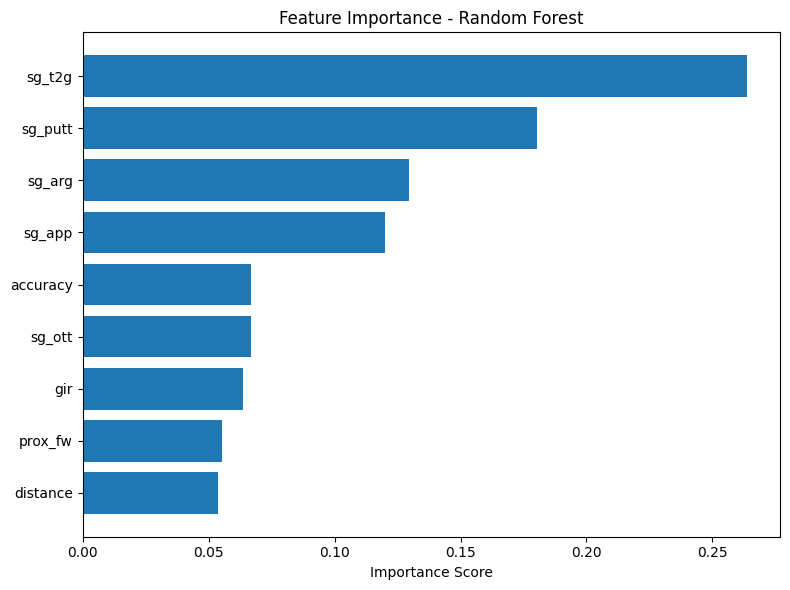


Top Features:
    Feature  Importance
4    sg_t2g    0.263635
0   sg_putt    0.180423
1    sg_arg    0.129537
2    sg_app    0.119838
6  accuracy    0.067015
3    sg_ott    0.066927
7       gir    0.063522
8   prox_fw    0.055257
5  distance    0.053845

MINIMUM STAT LINE TO MAKE THE CUT
sg_putt: -1.288
sg_arg: 1.705
sg_app: -0.182
sg_ott: -0.103
sg_t2g: 1.419
distance: 302.300
accuracy: 0.607
gir: 0.611
prox_fw: 37.174
Predicted probability of making cut: 0.508

10 WEAKEST PROFILES THAT STILL MAKE THE CUT
    sg_putt  sg_arg  sg_app  sg_ott  sg_t2g  distance  accuracy       gir  \
13  -1.2875  1.7055 -0.1825 -0.1030  1.4195    302.30  0.607145  0.611115   
17   1.3150 -2.0875  1.9415 -0.0370 -0.1830    297.05  0.785715  0.611110   
20  -1.4155  1.5845  1.6390  0.3240  3.5475    295.50  0.821425  0.666670   
61   0.2555 -1.3070  0.6870 -0.5035 -1.1235    298.25  0.500000  0.527775   
8   -0.7270  0.3020  1.9160  0.6405  2.8585    306.00  0.714285  0.805555   
36   0.7345 -1.5850  0.55

In [88]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "made_cut" not in df.columns:
        raise ValueError(
            "The cleaned dataset must contain 'made_cut'. "
            "Create it before removing total_score."
        )

    df["target"] = df["made_cut"].astype(int)

    return df


def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    X = df.select_dtypes(include="number").copy()

    drop_cols = ["target", "made_cut", "total_score", "avg_round_score"]
    existing_drop_cols = [col for col in drop_cols if col in X.columns]
    X = X.drop(columns=existing_drop_cols)

    X = X.fillna(X.mean())

    y = df["target"]

    return X, y


def build_random_forest(df: pd.DataFrame) -> tuple[RandomForestClassifier, pd.DataFrame, pd.Series]:
    X, y = prepare_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("RANDOM FOREST RESULTS")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return model, X, y


def plot_feature_importance(model: RandomForestClassifier, X: pd.DataFrame) -> pd.DataFrame:
    importances = model.feature_importances_
    features = X.columns

    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title("Feature Importance - Random Forest")
    plt.xlabel("Importance Score")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return importance_df


def find_minimum_stat_line(
    model: RandomForestClassifier,
    X: pd.DataFrame,
    y: pd.Series
) -> tuple[pd.Series, pd.DataFrame]:
    results = X.copy()
    results["actual_target"] = y.values
    results["pred_prob_make_cut"] = model.predict_proba(X)[:, 1]
    results["predicted_make_cut"] = model.predict(X)

    make_cut_profiles = results[results["predicted_make_cut"] == 1].copy()

    if make_cut_profiles.empty:
        raise ValueError("No players were predicted to make the cut.")

    make_cut_profiles = make_cut_profiles.sort_values(
        by="pred_prob_make_cut",
        ascending=True
    )

    minimum_profile = make_cut_profiles.iloc[0]

    return minimum_profile, make_cut_profiles


def print_minimum_stat_line(minimum_profile: pd.Series) -> None:
    print("\nMINIMUM STAT LINE TO MAKE THE CUT")

    for col, value in minimum_profile.items():
        if col not in ["actual_target", "pred_prob_make_cut", "predicted_make_cut"]:
            print(f"{col}: {value:.3f}")

    print(f"Predicted probability of making cut: {minimum_profile['pred_prob_make_cut']:.3f}")


def main() -> None:
    df = pd.read_csv(r"C:\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv")

    df = prepare_data(df)

    model, X, y = build_random_forest(df)

    importance_df = plot_feature_importance(model, X)

    print("\nTop Features:")
    print(importance_df.head(10))

    minimum_profile, make_cut_profiles = find_minimum_stat_line(model, X, y)

    print_minimum_stat_line(minimum_profile)

    print("\n10 WEAKEST PROFILES THAT STILL MAKE THE CUT")
    print(make_cut_profiles.head(10))


if __name__ == "__main__":
    main()

In [89]:
print("TOTAL PLAYERS IN DATASET:", len(df))

TOTAL PLAYERS IN DATASET: 95


6. XB Boost model
- This code builds an XGBoost classification model to predict whether a golfer will make the cut. The target variable is made_cut, where 1 means the golfer made the cut and 0 means the golfer missed the cut.

- The program first prepares the dataset by checking that the made_cut column exists. It then creates a new column called target by converting made_cut into an integer value. This target column is what the model learns to predict.

- The code selects important golf performance features, including strokes gained putting, around the green, approach, off the tee, tee to green, greens in regulation, proximity to fairway, accuracy, and distance. Missing values are filled using the average value of each column so the model can run without errors.

- The data is split into training and testing sets using an 80/20 split. The XGBoost model is then trained using 300 trees, a maximum tree depth of 4, a learning rate of 0.05, and sampling settings that help reduce overfitting.

- After training, the model predicts both the cut outcome and the probability of making the cut for each golfer in the test set. The code evaluates performance using accuracy, a classification report, and a confusion matrix.

- The program also creates a feature importance chart. This chart shows which golf statistics had the strongest influence on the model’s predictions.
The code finds the weakest player statline that the XGBoost model still predicts will make the cut. It does this by predicting cut probabilities for all players, filtering to players predicted to make the cut, and selecting the player with the lowest cut probability. This creates a minimum statline that represents the closest profile to the cut line.



XGBOOST RESULTS
Accuracy: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.86      0.80         7
           1       0.91      0.83      0.87        12

    accuracy                           0.84        19
   macro avg       0.83      0.85      0.83        19
weighted avg       0.85      0.84      0.84        19


Confusion Matrix:
[[ 6  1]
 [ 2 10]]


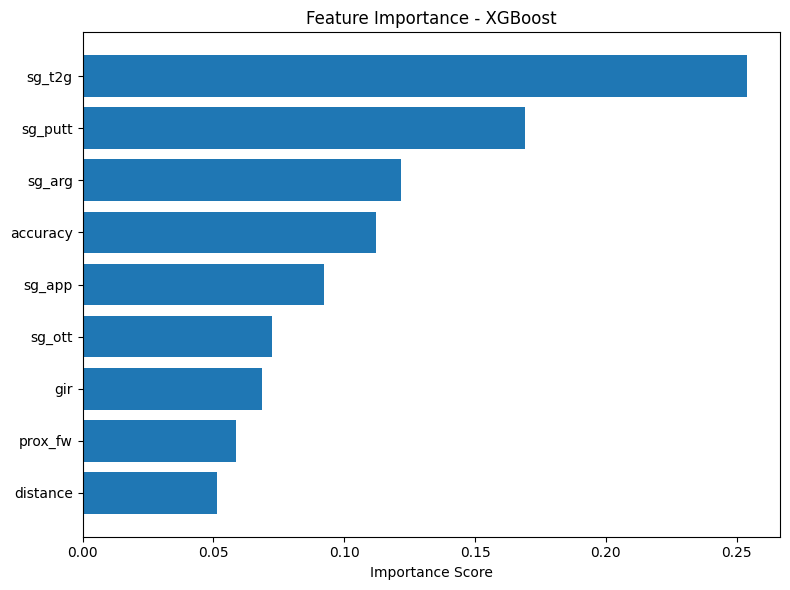


MINIMUM STATLINE TO MAKE THE CUT
--------------------------------
Player closest to cut line: Rahm, Jon
Predicted cut probability: 0.614

Required Statline:
sg_putt: -1.288
sg_arg: 1.705
sg_app: -0.182
sg_ott: -0.103
sg_t2g: 1.419
gir: 0.611
prox_fw: 37.174
accuracy: 0.607
distance: 302.300


In [90]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "made_cut" not in df.columns:
        raise ValueError("Dataset must contain 'made_cut' column.")

    df["target"] = df["made_cut"].astype(int)

    return df


def prepare_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    features = [col for col in features if col in df.columns]

    if len(features) == 0:
        raise ValueError("No valid features found in dataset.")

    X = df[features].copy()
    X = X.fillna(X.mean())

    y = df["target"]

    return X, y


def build_xgboost_model(df: pd.DataFrame):
    X, y = prepare_features(df)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print("\nXGBOOST RESULTS")
    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results = X_test.copy()
    results["actual"] = y_test.values
    results["predicted"] = y_pred
    results["cut_probability"] = y_prob

    return model, X, y, results


def plot_feature_importance(model, X: pd.DataFrame):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(8, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance"])
    plt.title("Feature Importance - XGBoost")
    plt.xlabel("Importance Score")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

    return importance_df


def find_minimum_statline(model, X: pd.DataFrame, df: pd.DataFrame):
    probabilities = model.predict_proba(X)[:, 1]
    predictions = model.predict(X)

    profiles = X.copy()
    profiles["predicted_make_cut"] = predictions
    profiles["cut_probability"] = probabilities

    if "player_name" in df.columns:
        profiles["player_name"] = df["player_name"].values

    make_cut_profiles = profiles[profiles["predicted_make_cut"] == 1].copy()

    if make_cut_profiles.empty:
        print("\nNo players were predicted to make the cut.")
        return None

    minimum_profile = make_cut_profiles.sort_values(
        by="cut_probability",
        ascending=True
    ).iloc[0]

    print("\nMINIMUM STATLINE TO MAKE THE CUT")
    print("--------------------------------")

    if "player_name" in minimum_profile.index:
        print("Player closest to cut line:", minimum_profile["player_name"])

    print("Predicted cut probability:", round(minimum_profile["cut_probability"], 3))

    print("\nRequired Statline:")
    for col in X.columns:
        print(f"{col}: {minimum_profile[col]:.3f}")

    return minimum_profile


def main():
    df = pd.read_csv(
        r"C:\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df = prepare_data(df)

    model, X, y, results = build_xgboost_model(df)

    importance_df = plot_feature_importance(model, X)

    find_minimum_statline(model, X, df)


if __name__ == "__main__":
    main()

7. Average the 2026 Master's dataset
- The code below is designed to create a new dataset by combining and averaging player statistics from two separate Masters tournament rounds. The goal is to produce a single dataset that represents each player’s average performance across both rounds, which can then be used for further analysis or modeling.

- The program begins by loading two datasets, one for Round 1 and one for Round 2. These datasets are read from CSV files and stored as pandas DataFrames. The code also prints the column names of each dataset to help verify that the structure is consistent and to identify the correct column used to match players across both rounds.

- The program identifies a common column that represents the player name. Since datasets may use different naming conventions, the code checks several possible column names such as “player”, “Player”, “player_name”, “name”, and “Name”. The first matching column found in both datasets is used as the key for merging.

- Once the key column is identified, the two datasets are merged using this column. Each numeric column from both datasets is preserved with suffixes indicating which round it came from (“_r1” for Round 1 and “_r2” for Round 2).

- The program then creates a new DataFrame to store the averaged results. It loops through all numeric columns and identifies pairs of columns representing the same statistic from each round. For each pair, it calculates the average value and stores it under the original column name. This results in a dataset where each statistic reflects the average performance across the two rounds.





In [91]:
def load_data(r1_path: str, r2_path: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    r1 = pd.read_csv(r1_path)
    r2 = pd.read_csv(r2_path)

    print("R1 Columns:", r1.columns.tolist())
    print("R2 Columns:", r2.columns.tolist())

    return r1, r2


def average_rounds(r1: pd.DataFrame, r2: pd.DataFrame) -> pd.DataFrame:
    r1 = r1.copy()
    r2 = r2.copy()

    possible_keys = ["player", "Player", "player_name", "name", "Name"]

    key = None
    for col in possible_keys:
        if col in r1.columns and col in r2.columns:
            key = col
            break

    if key is None:
        raise ValueError(f"No matching player column found. Columns are: {r1.columns.tolist()}")

    print(f"Using '{key}' as player identifier")

    merged = pd.merge(r1, r2, on=key, suffixes=("_r1", "_r2"))

    avg_df = pd.DataFrame()
    avg_df[key] = merged[key]

    numeric_cols = merged.select_dtypes(include="number").columns

    for col in numeric_cols:
        if col.endswith("_r1"):
            base = col[:-3]
            col_r2 = base + "_r2"

            if col_r2 in merged.columns:
                avg_df[base] = (merged[col] + merged[col_r2]) / 2

    return avg_df


def main():
    r1_path = r"C:\Users\sawye\Downloads\DataScience(1)\2026_masters_tournament_r1_values.csv"
    r2_path = r"C:\Users\sawye\Downloads\DataScience(1)\2026_masters_tournament_r2_values.csv"

    r1, r2 = load_data(r1_path, r2_path)

    avg_df = average_rounds(r1, r2)

    print("\nAVERAGED DATASET:")
    print(avg_df.head())

    # Save new dataset
    avg_df.to_csv("masters_avg_dataset.csv", index=False)
    print("\nSaved as masters_avg_dataset.csv")


if __name__ == "__main__":
    main()

R1 Columns: ['position', 'player_name', 'total_score', 'r1_score', 'sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'gir', 'prox_fw', 'accuracy', 'distance']
R2 Columns: ['position', 'player_name', 'total_score', 'r2_score', 'sg_putt', 'sg_arg', 'sg_app', 'sg_ott', 'sg_t2g', 'gir', 'prox_fw', 'accuracy', 'distance']
Using 'player_name' as player identifier

AVERAGED DATASET:
          player_name  total_score  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g  \
0       McIlroy, Rory        -12.0   2.3190  2.1995  2.7410  0.4880  5.4280   
1  Scheffler, Scottie        -11.0  -1.2055  0.6785  0.3305  1.9435  2.9525   
2        Rose, Justin        -10.0   0.1815  0.5445  2.7375  0.7835  4.0660   
3      Young, Cameron        -10.0   0.2275  0.1760  1.3840  1.9595  3.5195   
4     Henley, Russell        -10.0   0.5475 -0.6520  1.3930  0.4590  1.2005   

       gir   prox_fw  accuracy  distance  
0  0.72222  25.38865  0.464285    331.65  
1  0.63889  40.20415  0.821425    310.85  
2  0.77778  37.7

8. Finding the results of the 2026 Master's Cut
- This code compares 2026 Masters player statistics to the minimum performance levels of players who made the cut in 2025. The goal is to identify which 2026 players meet or exceed the lowest statistical marks from successful 2025 players.

- The program first uses the 2025 dataset to find players who made the cut. It filters the data to only include rows where made_cut equals 1.

- The code selects key golf performance features, including strokes gained putting, approach, off the tee, tee to green, greens in regulation, proximity to fairway, accuracy, and distance. For each feature, it calculates the minimum value among 2025 players who made the cut. This creates a baseline minimum statline.

- The second function applies that 2025 minimum statline to the 2026 dataset. It checks each 2026 player and keeps only players whose statistics are greater than or equal to every minimum value from the 2025 cut-making group.

- The program then prints the 2026 players who meet the 2025 minimum statline. It displays player names and their relevant performance statistics. Only the first 10 qualifying players are printed in the output.

- The programmed is repeated multiple times till it displays every single player that meets the minimum statline which is the players that are being predicted to make the cut.

In [92]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[:10]
    .to_string(index=False)
)


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
       player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
Scheffler, Scottie  -1.2055  0.6785  0.3305  1.9435  2.9525 0.638890 40.20415  0.821425    310.85
      Rose, Justin   0.1815  0.5445  2.7375  0.7835  4.0660 0.777780 37.71695  0.785710    305.80
    Young, Cameron   0.2275  0.1760  1.3840  1.9595  3.5195 0.666670 33.85575  0.892855    312.00
   Henley, Russell   0.5475 -0.6520  1.3930  0.4590  1.2005 0.638890 29.80145  0.821425    294.70
   Hatton, Tyrrell  -0.4350  1.3525  1.4600  1.3695  4.1820 0.750000 35.02215  0.821425    309.10
  Morikawa, Collin   2.1710  0.1205  0.3740 -0.4180  0.0760 0.583335 31.52095  0.714285    294.85
   

In [93]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[10:21]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
      player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
       Day, Jason   2.4450  1.0425  0.2280  0.0320  1.3025 0.611115 48.64015  0.678575    300.65
   Koepka, Brooks   0.3875  0.4690  2.1625  0.2280  2.8600 0.694445 31.50595  0.571430    314.35
 Cantlay, Patrick  -1.0590  0.7965  2.2740 -0.2640  2.8060 0.666665 29.45445  0.678575    300.90
Matsuyama, Hideki   2.1375  0.3740  0.3480 -0.1120  0.6095 0.666665 39.54200  0.678575    297.95
   Spieth, Jordan  -0.6960  0.3315  1.9980 -0.3865  1.9430 0.750000 36.50090  0.642860    305.35
    Reed, Patrick   2.2275  0.8625  0.8080  0.8495  2.5195 0.638890 40.42340  0.750000    303.90
McNealy, M

In [94]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[21:32]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
     player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
  Clark, Wyndham  -0.5825  1.3795  1.6415  1.3085  4.3300 0.777780 37.62885  0.857140    299.55
 Gotterup, Chris  -0.0080  1.1900  1.0425  1.0230  3.2555 0.722220 40.80555  0.642860    318.60
    Stevens, Sam  -0.3135  0.1790  0.7335  0.1490  1.0610 0.611110 38.91695  0.642855    307.85
 Campbell, Brian   2.0125  1.1670 -0.7055 -0.7270 -0.2655 0.444445 40.52320  0.714285    284.05
     Scott, Adam   0.1150  0.1710 -0.1795  0.6410  0.6325 0.555555 35.56845  0.821425    302.20
   McCarty, Matt   0.6800  0.8105 -0.4345  0.1910  0.5670 0.638890 36.44675  0.750000    305.35
Brennan, Michael 

In [95]:



def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[32:43]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
     player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
Fleetwood, Tommy   2.5650 -0.0295  0.9820  0.7300  1.6825 0.638890 34.69785  0.857140    301.30
  Woodland, Gary   1.3830 -0.3545 -0.9450  0.6645 -0.6350 0.555555 35.25030  0.678575    317.70
    Griffin, Ben   2.7775  0.6245  0.1070 -0.2620  0.4695 0.611110 47.05355  0.571430    301.35
   Harman, Brian  -0.3430 -0.0060 -0.2325  0.3290  0.0905 0.611110 38.21830  0.785715    293.65
       Rahm, Jon  -1.4765  0.0015 -0.1760  1.3990  1.2240 0.638890 30.79890  0.750000    313.05
    Gerard, Ryan   2.6360 -0.9780  0.7600 -0.6710 -0.8885 0.611110 35.21255  0.678575    300.40
     Li, Haotong 

In [96]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[43:54]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
       player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
Reitan, Kristoffer   2.7525  1.0275 -0.7875  0.7550  0.9950 0.666670 41.52940  0.607145    312.40
       Im, Sungjae   1.4230  1.2680 -2.4890  1.0450 -0.1755 0.611115 55.64300  0.857140    307.05
       Kim, Si Woo  -0.8595 -0.1400  0.4745  0.2730  0.6070 0.611110 36.11005  0.678575    300.85
        Rai, Aaron  -0.6095  0.3365  0.6900  0.8305  1.8565 0.694445 51.38420  0.928570    291.35
    Conners, Corey  -0.7220  1.3860  0.7295 -1.6460  0.4690 0.638890 29.41330  0.750000    291.00
      Penge, Marco   1.2835  0.6800 -1.6035  0.8875 -0.0365 0.500000 40.09910  0.571430    321.45
   

In [97]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[54:65]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
      player_name  sg_putt  sg_arg  sg_app  sg_ott  sg_t2g      gir  prox_fw  accuracy  distance
      Hall, Harry   0.1450 -0.7910  0.5995 -0.7060 -0.8975 0.583335 49.48915  0.642860    291.40
        Fox, Ryan  -0.8795  0.2505 -0.1480  0.0245  0.1265 0.694445 40.77335  0.678575    312.40
Hojgaard, Nicolai  -1.3930 -0.7020  0.1115  0.7315  0.1410 0.638890 38.98690  0.678575    316.35
    Johnson, Zach  -0.8170  0.1470 -0.8375  0.2545 -0.4360 0.638890 43.76160  0.857140    288.00
    Novak, Andrew  -0.6385 -0.9940 -0.3025  0.1825 -1.1140 0.583335 51.96695  0.785715    301.00
    McKibbin, Tom  -2.0230 -0.0060 -0.9405  1.2165  0.2700 0.694445 39.08725  0.892855    305.80
   Berger,

In [98]:
def get_minimum_statline_2025(df_2025: pd.DataFrame) -> pd.Series:
    features = [
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]

    made_cut_players = df_2025[df_2025["made_cut"] == 1]

    minimum_statline = made_cut_players[features].min()

    print("\n2025 MINIMUM STATLINE TO MAKE THE CUT")
    print("------------------------------------")
    for stat, value in minimum_statline.items():
        print(f"{stat}: {value:.3f}")

    return minimum_statline


def predict_2026_from_minimum_statline(
    df_2026: pd.DataFrame,
    minimum_statline: pd.Series
) -> pd.DataFrame:

    qualified_players = df_2026.copy()

    for stat, minimum_value in minimum_statline.items():
        qualified_players = qualified_players[
            qualified_players[stat] >= minimum_value
        ]

    print("\n2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE")
    print("------------------------------------------------")

    
    print(
    qualified_players[[
        "player_name",
        "sg_putt",
        "sg_arg",
        "sg_app",
        "sg_ott",
        "sg_t2g",
        "gir",
        "prox_fw",
        "accuracy",
        "distance"
    ]]
    .iloc[65:76]
    .to_string(index=False)
    )


    return qualified_players


def main():
    df_2025 = pd.read_csv(
        r"C:\\Users\sawye\Downloads\DataScience(1)\masters_avg_dataset_cleaned.csv"
    )

    df_2026 = pd.read_csv(
        r"masters_avg_dataset.csv"
    )

    minimum_statline = get_minimum_statline_2025(df_2025)

    qualified_players = predict_2026_from_minimum_statline(
        df_2026,
        minimum_statline
    )

    qualified_players.to_csv(
        "2026_players_meeting_2025_minimum_statline.csv",
        index=False
    )


if __name__ == "__main__":
    main()


2025 MINIMUM STATLINE TO MAKE THE CUT
------------------------------------
sg_putt: -2.571
sg_arg: -2.088
sg_app: -2.768
sg_ott: -1.726
sg_t2g: -1.712
gir: 0.417
prox_fw: 27.473
accuracy: 0.500
distance: 264.000

2026 PLAYERS WHO MEET THE 2025 MINIMUM STATLINE
------------------------------------------------
Empty DataFrame
Columns: [player_name, sg_putt, sg_arg, sg_app, sg_ott, sg_t2g, gir, prox_fw, accuracy, distance]
Index: []


9. Conclusion

- The model predicted 52/64 players correctly that they would make the cut 

- Of the 54 players that actually made the cut this year it predicted that 52 of them correctly would make the cut



- Every Player to make the 2026 Master's cut

1. Scheffler, Scottie  y
2. Rose, Justin   y
3. Young, Cameron   y
4. Henley, Russell   y
5. Hatton, Tyrrell  y
6. Morikawa, Collin   y
7. Burns, Sam   y
8. Schauffele, Xander  y
9. Homa, Max   y
10. Knapp, Jake  y
11. Day, Jason   y
12.  Koepka, Brooks   y
13. Cantlay, Patrick  y
14. Matsuyama, Hideki   y
15. Spieth, Jordan  y
16. Reed, Patrick   y
17. McNealy, Maverick  y
18. Hovland, Viktor   y
19. Fitzpatrick, Matt   y
20. Aberg, Ludvig    y
21. Bradley, Keegan   y 
22. Clark, Wyndham  y
23. Gotterup, Chris   y
24. Stevens, Sam   y
25. Campbell, Brian   y
26. Scott, Adam   y
27. McCarty, Matt   y
28. Brennan, Michael   y
29. Noren, Alex   y
30. English, Harris   y
31. Lowry, Shane   y
32. Johnson, Dustin  y
33. Fleetwood, Tommy  y
34. Woodland, Gary   y
35. Griffin, Ben   y
36. Harman, Brian  y
37. Rahm, Jon  y
38. Gerard, Ryan   y
39. Li, Haotong   y
40. Thomas, Justin   y
41. Bridgeman, Jacob  y
42. Straka, Sepp   y
43. Taylor, Nick   y
44. Reitan, Kristoffer   y
45. Im, Sungjae  y
46. Kim, Si Woo  y
47. Rai, Aaron   y
48. Conners, Corey  y
49. Penge, Marco   y
50. Garcia, Sergio   y
51. Hojgaard, Rasmus   y
52. Schwartzel, Charl   y
53. Watson, Bubba   n
54. Spaun, J.J  n 
55. Hall, Harry   n
56. Fox, Ryan   n
57. Hojgaard, Nicolai  n
58. Johnson, Zach  n
59. Novak, Andrew   n
60. McKibbin, Tom   n
61. Berger, Daniel  n
62. Jarvis, Casey   n
63. Howell, Mason  n
64. Singh, Vijay   n